# Titanic Data Visualization - Instructor-Led Practice

## Unit 2, Day 3
**Instructor:** Abishek Ganesh

---

## Today's Goal

We're going to take the Titanic dataset we explored on Day 2 and bring it to life with **visualizations**.

Data analysis is about finding insights. But insights are hard to see in rows and columns of numbers. **Charts and graphs help us SEE the story in our data.**

---

### What We'll Cover

| Chart Type | Best For |
|------------|----------|
| Bar Chart | Comparing categories |
| Histogram | Showing distribution of numbers |
| Pie Chart | Showing parts of a whole |
| Scatter Plot | Relationship between two numbers |
| Box Plot | Distribution + spotting outliers |

For each chart, we'll learn:
1. **When to use it** 
2. **When NOT to use it**
3. **How to build it**
4. **How to customize it**

---

**Follow along with me!** Run each cell as we go through it together.

---

# Section 1: Setup & Data Review

Let's import our libraries and load the Titanic data.

In [109]:
 # Import our libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [110]:
# Load the Titanic dataset
df_titanic = pd.read_csv('./titanic.csv')

# Quick reminder of what we're working with
print(f"Dataset shape: {df_titanic.shape}")
print(f"\nColumns: {list(df_titanic.columns)}")

Dataset shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [111]:
# Quick look at our data
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Quick Refresher: What's in our data?

| Column | Description |
|--------|-------------|
| Survived | 0 = No, 1 = Yes |
| Pclass | Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| Sex | male or female |
| Age | Age in years |
| SibSp | # of siblings/spouses aboard |
| Parch | # of parents/children aboard |
| Fare | Ticket price |
| Embarked | Port: C = Cherbourg, Q = Queenstown, S = Southampton |

---

## 🔧 New Pandas Tools for Today

Before we start making charts, we need to learn a few new Pandas commands that help us **prepare data for visualization**.

### `value_counts()` - Count unique values

This counts how many times each unique value appears in a column.

```python
df_titanic['Pclass'].value_counts()
```
**Output:**
```
3    491    ← 491 passengers in 3rd class
1    216    ← 216 passengers in 1st class
2    184    ← 184 passengers in 2nd class
```

**Think of it like:** "How many of each do I have?"

---

### `sort_index()` - Sort by the labels

After `value_counts()`, the results are sorted by count (highest first). Use `sort_index()` to sort by the category labels instead.

```python
df_titanic['Pclass'].value_counts().sort_index()
```
**Output:**
```
1    216    ← Now sorted by class number (1, 2, 3)
2    184
3    491
```

**Think of it like:** "Put these in order by their names/numbers."

---

### `groupby()` - Group data and calculate something

This groups your data by a column, then lets you calculate something (like sum, mean, count) for each group.

```python
df_titanic.groupby('Sex')['Survived'].sum()
```
**What this does:**
1. Group all rows by 'Sex' (male vs female)
2. Look at the 'Survived' column for each group
3. Add up (sum) the values

**Output:**
```
female    233    ← 233 females survived
male      109    ← 109 males survived
```

**Think of it like:** "Split into groups, then calculate for each group."

---

### `dropna()` - Remove missing values

Some columns have missing data (NaN = "Not a Number"). `dropna()` removes rows with missing values.

```python
df_titanic['Age'].dropna()
```

**Why we need this:** Charts can't plot missing values! If we try to make a histogram of Age without removing NaN values, we might get errors or weird results.

**Think of it like:** "Skip the blanks."

---

Let's see these in action as we build our charts!

---

# Section 2: Bar Charts

Bar charts are one of the most common and useful chart types.

## When to Use a Bar Chart

**✅ USE bar charts when:**
- Comparing **categories** (like passenger class, gender, cities)
- Showing **counts or totals** for different groups
- You want to clearly see which category is bigger/smaller

**❌ DON'T use bar charts when:**
- Showing **continuous data** (like age distribution) - use a histogram instead
- Showing **trends over time** - use a line chart instead
- You have **too many categories** (20+ bars become hard to read)

---

**Think of it this way:** Bar charts answer "How many of each type do we have?"

In [112]:
# First, let's get the data we need
# Count passengers by class using value_counts()
# Then sort_index() puts them in order: 1, 2, 3 (instead of by count)
class_counts = df_titanic['Pclass'].value_counts().sort_index()
print(class_counts)
print()
print("^ This shows: 216 in 1st class, 184 in 2nd class, 491 in 3rd class")

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

^ This shows: 216 in 1st class, 184 in 2nd class, 491 in 3rd class


In [113]:
# First, let's get the data we need
# Count passengers by class
class_counts = df_titanic['Pclass'].value_counts().sort_index()
print(class_counts)

Pclass
1    216
2    184
3    491
Name: count, dtype: int64


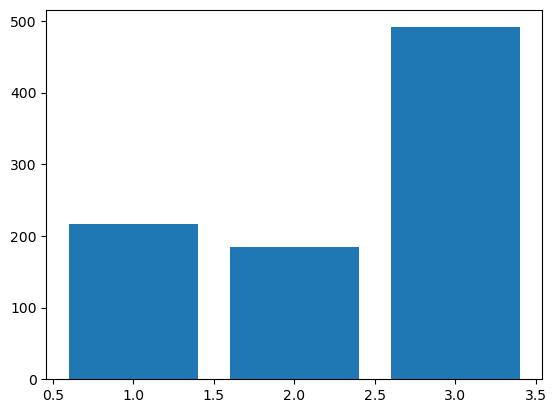

In [114]:
# Basic bar chart
plt.bar(class_counts.index, class_counts.values)
plt.show()

That works, but it's not very informative. Let's customize it!

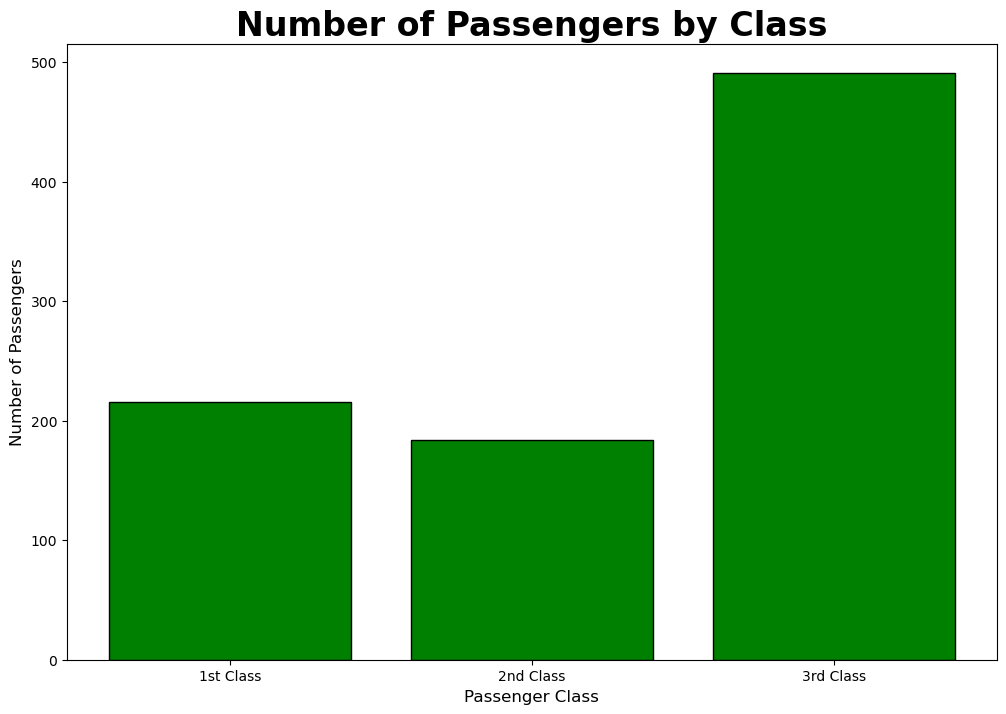

In [115]:
# Customized bar chart
plt.figure(figsize=(12, 8))  # Set figure size (width, height in inches)

# Create the bars with a nice color
plt.bar(class_counts.index, class_counts.values, color='green', edgecolor='black')

# Add title and labels
plt.title('Number of Passengers by Class', fontsize=24, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Make x-axis labels clearer
plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])

plt.show()

### 💡 Insight
What do you notice? **3rd class had the most passengers** - almost as many as 1st and 2nd class combined!

In [116]:
# Count survivors by gender using groupby()
# Step 1: groupby('Sex') splits data into male and female groups
# Step 2: ['Survived'] looks at just the Survived column
# Step 3: .sum() adds up the 1s (survivors) in each group
survival_by_gender = df_titanic.groupby('Sex')['Survived'].sum()
print(survival_by_gender)
print()
print("^ This shows: 233 females survived, 109 males survived")

Sex
female    233
male      109
Name: Survived, dtype: int64

^ This shows: 233 females survived, 109 males survived


In [117]:
# Count survivors by gender
survival_by_gender = df_titanic.groupby('Sex')['Survived'].sum()
print(survival_by_gender)

Sex
female    233
male      109
Name: Survived, dtype: int64


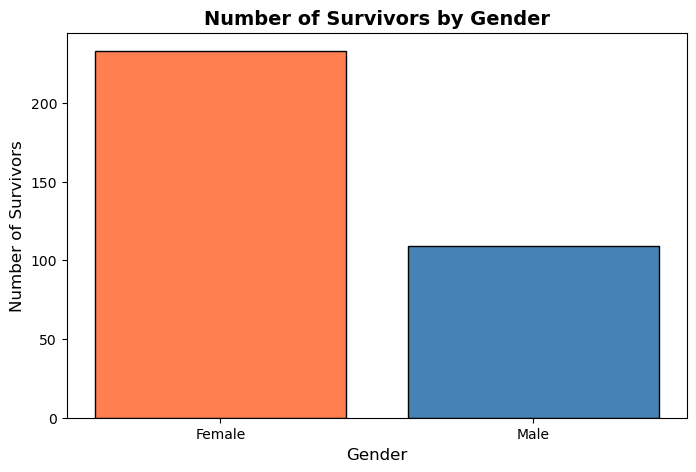

In [118]:
# Customized bar chart with different colors for each bar
plt.figure(figsize=(8, 5))

colors = ['coral', 'steelblue']  # Different color for each bar
plt.bar(survival_by_gender.index, survival_by_gender.values, color=colors, edgecolor='black')

plt.title('Number of Survivors by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Survivors', fontsize=12)

# Capitalize the x-axis labels
plt.xticks(['female', 'male'], ['Female', 'Male'])

plt.show()

---

### 🎯 Your Turn: Bar Chart Practice

**Challenge:** Create a bar chart showing how many passengers embarked from each port.

The `Embarked` column has 3 values:
- S = Southampton
- C = Cherbourg  
- Q = Queenstown

**Your task:**
1. Count passengers by embarkation port (use `value_counts()`)
2. Create a bar chart with those counts
3. Add a title, axis labels, and nice colors
4. Replace S, C, Q with the full port names on the x-axis

**Hint:** Start with `port_counts = df_titanic['Embarked'].value_counts()`

---

### 🎯 Your Turn: Bar Chart Practice

**Challenge:** Create a bar chart showing how many passengers embarked from each port.

The `Embarked` column has 3 values:
- S = Southampton
- C = Cherbourg  
- Q = Queenstown

**Your task:**
1. Count passengers by embarkation port
2. Create a bar chart with those counts
3. Add a title, axis labels, and nice colors
4. Replace S, C, Q with the full port names on the x-axis


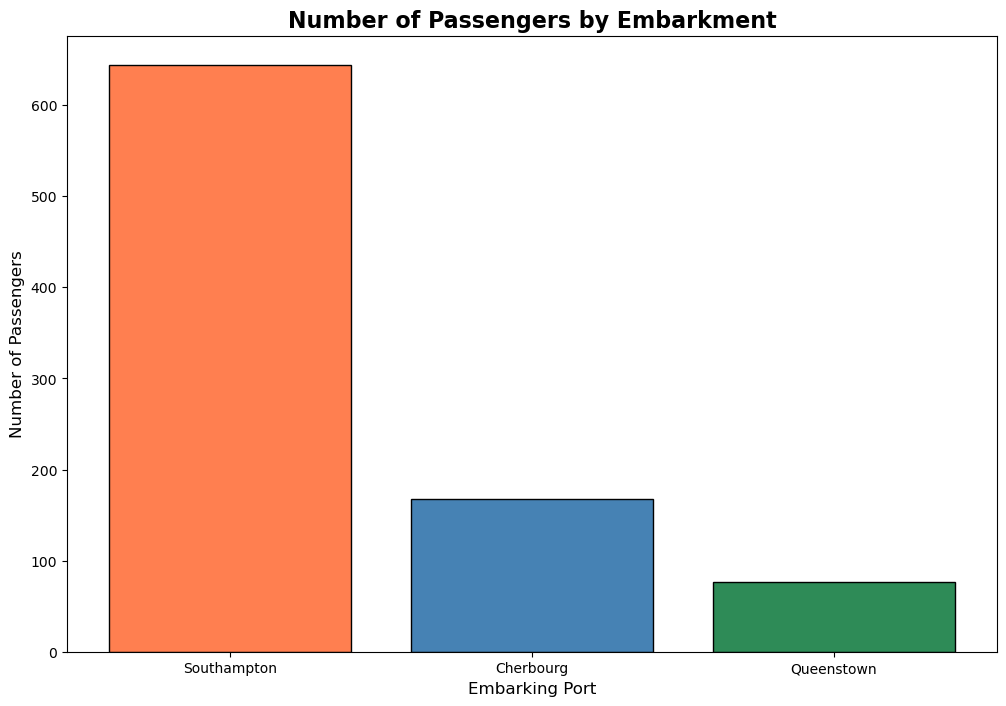

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [144]:
# Your Turn: Bar Chart - Passengers by Embarkation Port
# Write your code here!

port_counts = df_titanic['Embarked'].value_counts()
colors = ['coral', 'steelblue', 'seagreen']
# Customized bar chart
plt.figure(figsize=(12, 8))  # Set figure size (width, height in inches)

# Create the bars with a nice color
plt.bar(port_counts.index, port_counts.values, color=colors, edgecolor='black')

# Add title and labels
plt.title('Number of Passengers by Embarkment', fontsize=16, fontweight='bold')
plt.xlabel('Embarking Port', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Make x-axis labels clearer
plt.xticks(['S', 'C', 'Q'], ['Southampton', 'Cherbourg', 'Queenstown'])

plt.show()
port_counts

---

# Section 3: Histograms

Histograms look similar to bar charts, but they serve a completely different purpose.

## When to Use a Histogram

**✅ USE histograms when:**
- Showing the **distribution** of continuous/numerical data
- You want to see where most values fall (the "shape" of your data)
- Identifying if data is **skewed**, **normal**, or has **multiple peaks**

**❌ DON'T use histograms when:**
- Comparing **categories** - use a bar chart instead
- You have **categorical data** (like gender or city names)
- You want to show **exact values** - histograms group data into bins

---

**Think of it this way:** Histograms answer "How is my data spread out?" or "What's the most common range?"

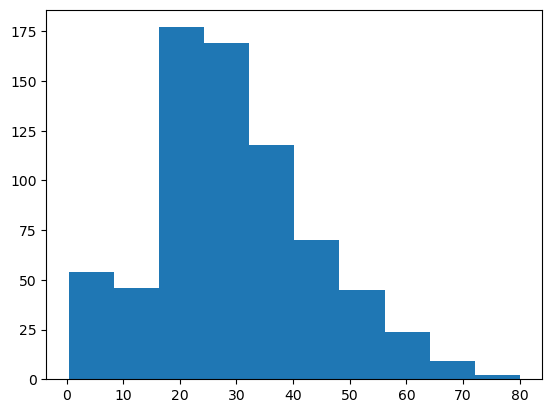

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
886    27.0
887    19.0
889    26.0
890    32.0
Name: Age, Length: 714, dtype: float64

In [120]:
# Basic histogram
# dropna() removes the 177 passengers with missing Age values
# Without dropna(), we'd get errors or weird results
plt.hist(df_titanic['Age'].dropna())
plt.show()

df_titanic['Age'].dropna()

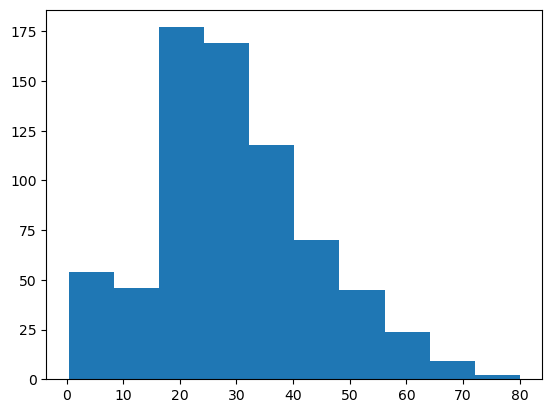

In [121]:
# Basic histogram
plt.hist(df_titanic['Age'].dropna())  # dropna() removes missing values
plt.show()

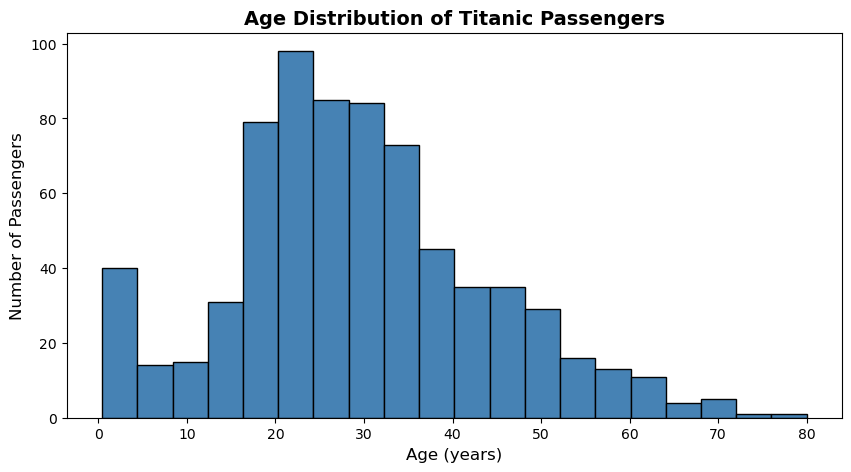

In [122]:
# Customized histogram
plt.figure(figsize=(10, 5))

# bins = how many "buckets" to divide the data into
plt.hist(df_titanic['Age'].dropna(), bins=20, color='steelblue', edgecolor='black')

plt.title('Age Distribution of Titanic Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

plt.show()

### 💡 Insight
**Most passengers were young adults (20-30 years old).** There were also quite a few children (0-10) and the numbers drop off significantly after 50.

### The Power of Bins

The number of bins changes how the histogram looks. Let's see the difference:

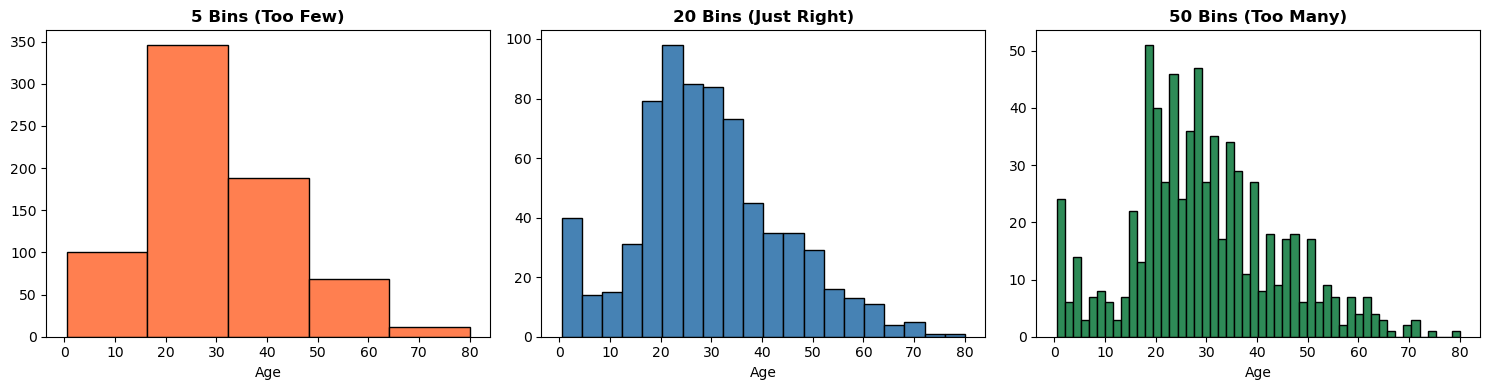

In [123]:
# Compare different bin sizes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ages = df_titanic['Age'].dropna()

# Too few bins - loses detail
axes[0].hist(ages, bins=5, color='coral', edgecolor='black')
axes[0].set_title('5 Bins (Too Few)', fontweight='bold')
axes[0].set_xlabel('Age')

# Good number of bins
axes[1].hist(ages, bins=20, color='steelblue', edgecolor='black')
axes[1].set_title('20 Bins (Just Right)', fontweight='bold')
axes[1].set_xlabel('Age')

# Too many bins - too noisy
axes[2].hist(ages, bins=50, color='seagreen', edgecolor='black')
axes[2].set_title('50 Bins (Too Many)', fontweight='bold')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

**Pro tip:** Start with 10-20 bins and adjust based on what looks clearest for your data.

### Let's Build Another: Fare Distribution

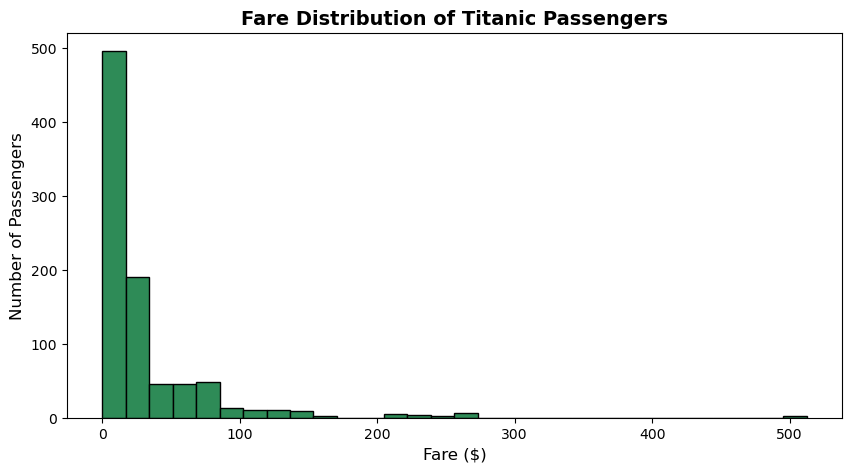

In [124]:
# Fare distribution
plt.figure(figsize=(10, 5))

plt.hist(df_titanic['Fare'], bins=30, color='seagreen', edgecolor='black')

plt.title('Fare Distribution of Titanic Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Fare ($)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

plt.show()

### 💡 Insight
This histogram is **heavily right-skewed**! Most passengers paid under $50, but there are some who paid over $500. Those are likely 1st class passengers in luxury cabins.

---

### 🎯 Your Turn: Histogram Practice

**Challenge:** Create a histogram showing the distribution of `SibSp` (number of siblings/spouses aboard).

**Your task:**
1. Create a histogram of the `SibSp` column
2. Experiment with different bin sizes (try 8-10 bins)
3. Add a title and axis labels
4. Choose a color you like

**Discussion question:** What do you notice about this distribution? Is it skewed? Where do most values fall?

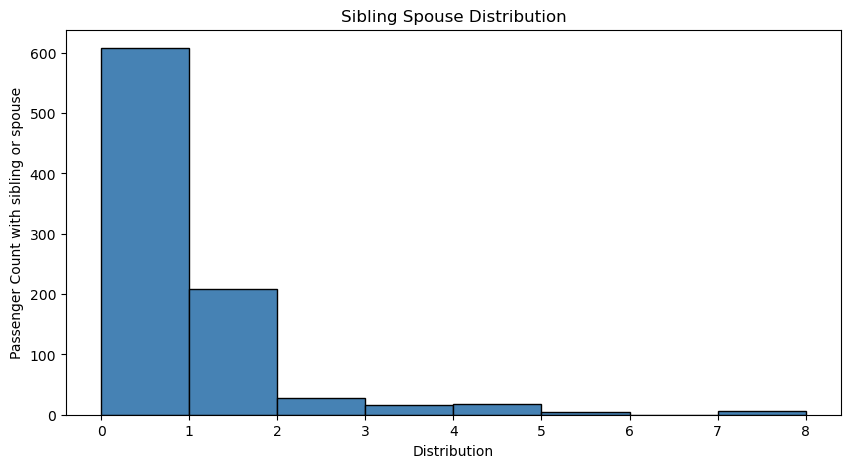

SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

In [125]:
# Your Turn: Histogram - SibSp Distribution
# Write your code here!


plt.figure(figsize=(10, 5))

plt.hist(df_titanic['SibSp'], bins=8, color='steelblue', edgecolor='black')
plt.title("Sibling Spouse Distribution")
plt.xlabel("Distribution")
plt.ylabel("Passenger Count with sibling or spouse")

plt.show()

df_titanic['SibSp'].value_counts().sort_index()


---

# Section 4: Pie Charts

Pie charts get a bad reputation, but they're useful in the right situations.

## When to Use a Pie Chart

**✅ USE pie charts when:**
- Showing **parts of a whole** (percentages that add up to 100%)
- You have **2-5 categories** (simple and clear)
- One slice is dramatically different from others (easy to see)

**❌ DON'T use pie charts when:**
- You have **more than 5-6 categories** - becomes cluttered and hard to read
- Categories have **similar values** - hard to compare slice sizes
- You want to compare **exact numbers** - bar charts are better for this
- Showing **changes over time** - use line or bar charts

---

**Think of it this way:** Pie charts answer "What portion of the total is this?"

In [126]:
# Get survival counts using value_counts()
# This counts how many 0s (didn't survive) and 1s (survived) we have
survival_counts = df_titanic['Survived'].value_counts()
print(survival_counts)
print()
print("^ 0 means 'did not survive' (549 passengers)")
print("  1 means 'survived' (342 passengers)")

Survived
0    549
1    342
Name: count, dtype: int64

^ 0 means 'did not survive' (549 passengers)
  1 means 'survived' (342 passengers)


In [127]:
# Get survival counts
survival_counts = df_titanic['Survived'].value_counts()
print(survival_counts)

Survived
0    549
1    342
Name: count, dtype: int64


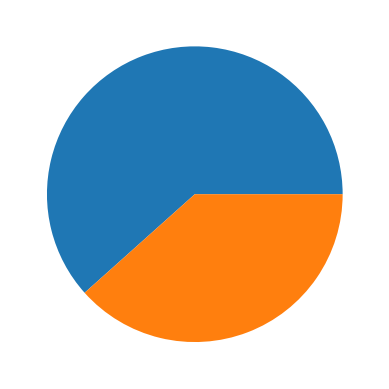

In [128]:
# Basic pie chart
plt.pie(survival_counts)
plt.show()

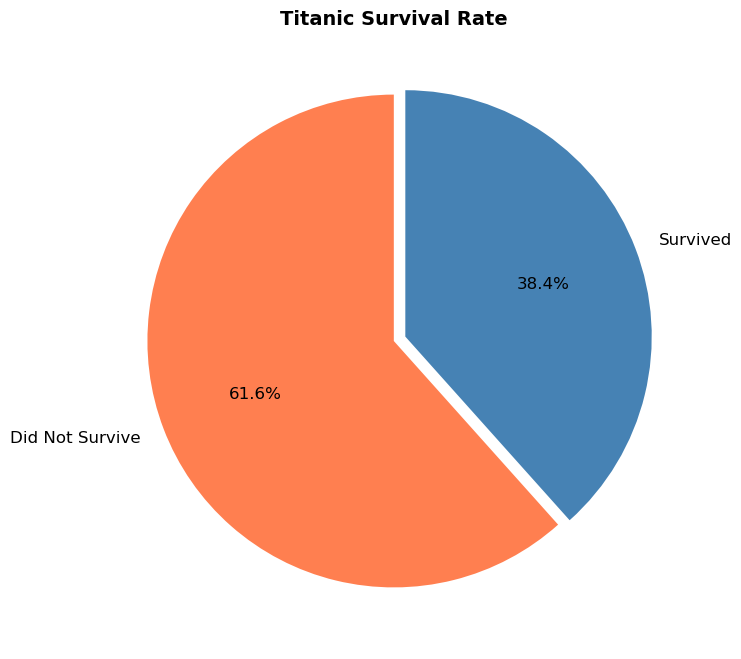

In [129]:
# Customized pie chart
plt.figure(figsize=(8, 8))

labels = ['Did Not Survive', 'Survived']
colors = ['coral', 'steelblue']
explode = (0, 0.05)  # "Pop out" the Survived slice slightly

plt.pie(survival_counts, 
        labels=labels, 
        colors=colors,
        explode=explode,
        autopct='%1.1f%%',  # Show percentages with 1 decimal
        startangle=90,      # Start from the top
        textprops={'fontsize': 12})

plt.title('Titanic Survival Rate', fontsize=14, fontweight='bold')

plt.show()


### 💡 Insight
**Only about 38% of passengers survived** the Titanic disaster. Nearly 2 out of every 3 passengers did not survive.

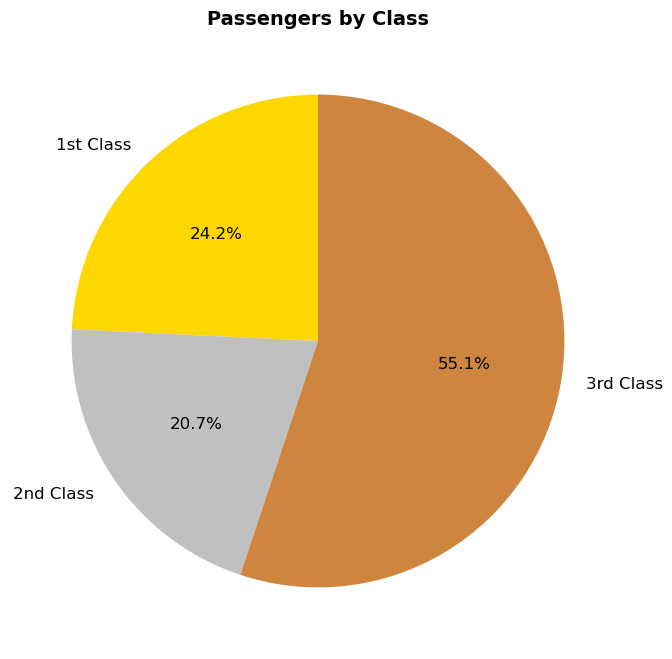

In [130]:
# Passenger class counts
# value_counts() counts each class, sort_index() puts them in order 1, 2, 3
class_counts = df_titanic['Pclass'].value_counts().sort_index()

plt.figure(figsize=(8, 8))

labels = ['1st Class', '2nd Class', '3rd Class']
colors = ['gold', 'silver', 'peru']
# explode = (0, 0.05) 

plt.pie(class_counts, 
        labels=labels, 
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12})

plt.title('Passengers by Class', fontsize=14, fontweight='bold')

plt.show()

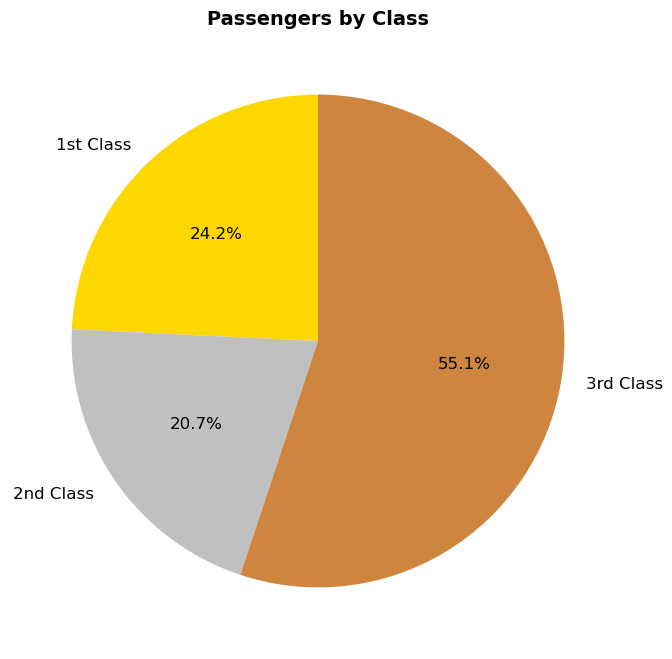

In [131]:
# Passenger class counts
class_counts = df_titanic['Pclass'].value_counts().sort_index()

plt.figure(figsize=(8, 8))

labels = ['1st Class', '2nd Class', '3rd Class']
colors = ['gold', 'silver', 'peru']

plt.pie(class_counts, 
        labels=labels, 
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12})

plt.title('Passengers by Class', fontsize=14, fontweight='bold')

plt.show()

---

### 🎯 Your Turn: Pie Chart Practice

**Challenge:** Create a pie chart showing the gender breakdown of passengers (male vs female).

**Your task:**
1. Count passengers by gender (use `value_counts()`)
2. Create a pie chart with those counts
3. Add labels ("Male", "Female"), percentages, and a title
4. Choose colors that make sense for your chart

**Hint:** Start with `gender_counts = df_titanic['Sex'].value_counts()`

**Discussion question:** Does this pie chart work well? Why or why not? (Think about the "when to use" guidelines!)

---

### 🎯 Your Turn: Pie Chart Practice

**Challenge:** Create a pie chart showing the gender breakdown of passengers (male vs female).

**Your task:**
1. Count passengers by gender using `value_counts()`
2. Create a pie chart with those counts
3. Add labels ("Male", "Female"), percentages, and a title
4. Choose colors that make sense for your chart

**Discussion question:** Does this pie chart work well? Why or why not? (Think about the "when to use" guidelines!)

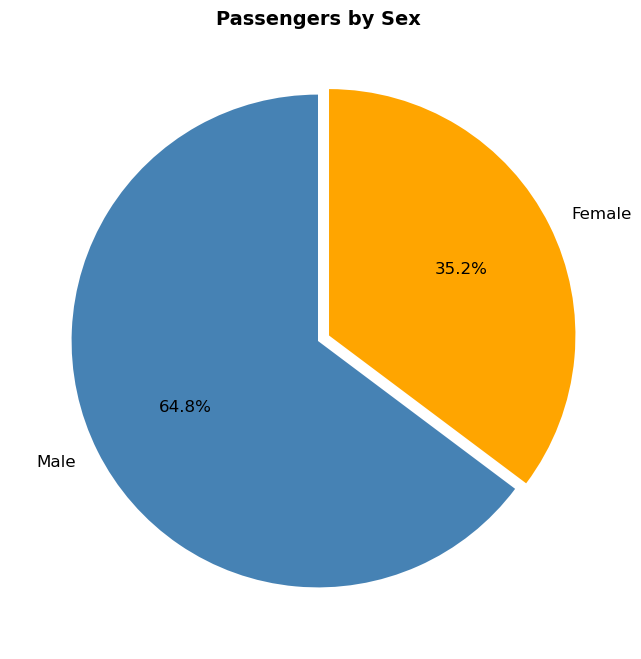

In [132]:
# Your Turn: Pie Chart - Gender Breakdown
# Write your code here!

sex_data = df_titanic['Sex'].value_counts()

plt.figure(figsize=(8, 8))

labels = ['Male', 'Female']
colors = ['steelblue', 'orange']
explode = (0, 0.05) 

plt.pie(sex_data,
        labels=labels, 
        explode=explode,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12}
        )

plt.title('Passengers by Sex', fontsize=14, fontweight='bold')
plt.show()

---

# Section 5: Scatter Plots

Scatter plots are powerful for exploring relationships between two numerical variables.

## When to Use a Scatter Plot

**✅ USE scatter plots when:**
- Exploring the **relationship between two numerical variables**
- Looking for **patterns, trends, or correlations**
- Identifying **outliers** (points far from the rest)
- You have a lot of individual data points to plot

**❌ DON'T use scatter plots when:**
- One or both variables are **categorical** - use bar charts instead
- You have **very few data points** (less than ~10)
- You want to show **exact values** - a table might be better

---

**Think of it this way:** Scatter plots answer "Is there a relationship between these two things?"

### Let's Build: Age vs Fare

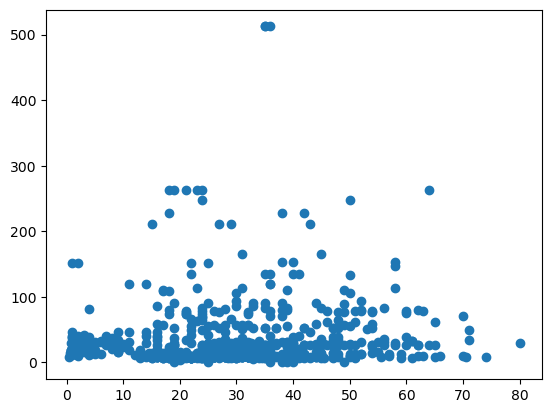

In [133]:
# Basic scatter plot
plt.scatter(df_titanic['Age'], df_titanic['Fare'])
plt.show()

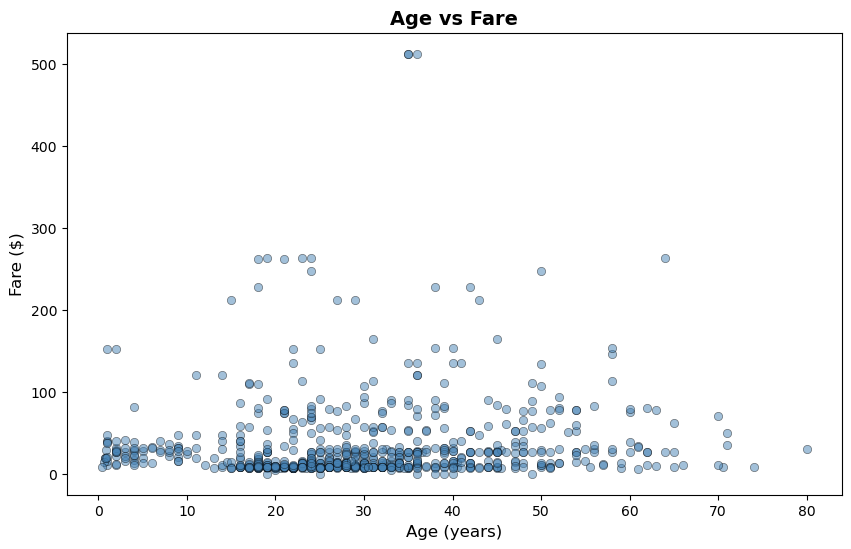

In [134]:
# Customized scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(df_titanic['Age'], df_titanic['Fare'], 
            alpha=0.5,           # Transparency (0-1) to see overlapping points
            color='steelblue',
            edgecolor='black',
            linewidth=0.5)

plt.title('Age vs Fare', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)

plt.show()

### 💡 Insight
There doesn't seem to be a strong relationship between age and fare. However, we can see some **outliers** - passengers who paid $500+ for their tickets! Also notice most data points are clustered in the bottom-left (younger passengers paying lower fares).

### Adding a Third Dimension: Color by Survival

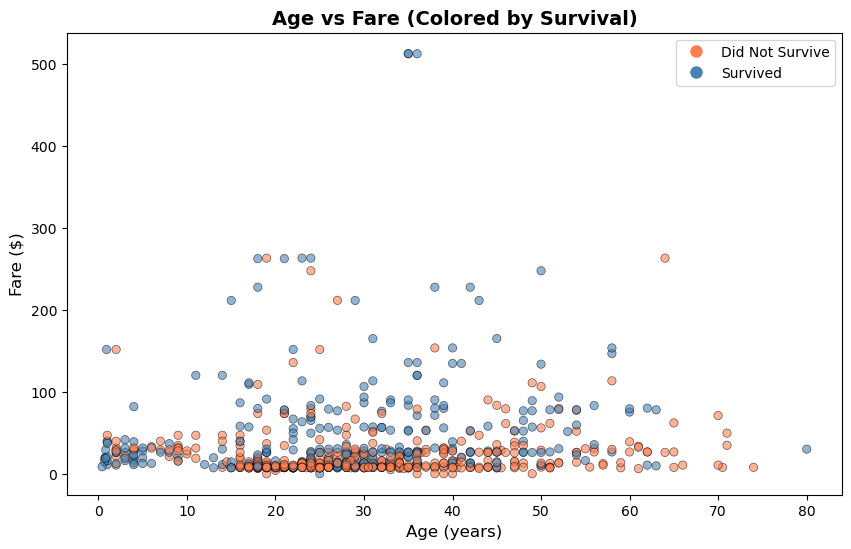

0          coral
1      steelblue
2      steelblue
3      steelblue
4          coral
         ...    
886        coral
887    steelblue
888        coral
889    steelblue
890        coral
Name: Survived, Length: 891, dtype: object

In [143]:
# Scatter plot with color representing survival
plt.figure(figsize=(10, 6))

# Create colors based on survival
colors = df_titanic['Survived'].map({0: 'coral', 1: 'steelblue'})

plt.scatter(df_titanic['Age'], df_titanic['Fare'], 
            c=colors,
            alpha=0.6,
            edgecolor='black',
            linewidth=0.5)

plt.title('Age vs Fare (Colored by Survival)', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)

# Add a simple legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='coral', markersize=10, label='Did Not Survive'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Survived')]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()
colors


### 💡 Insight
Now we can see survival patterns! Notice how the high-fare passengers (top of the chart) tend to be more blue (survived). Those were likely 1st class passengers who had better access to lifeboats.

---

### 🎯 Your Turn: Scatter Plot Practice

**Challenge:** Create a scatter plot exploring the relationship between `SibSp` (siblings/spouses) and `Parch` (parents/children).

**Your task:**
1. Create a scatter plot with `SibSp` on the x-axis and `Parch` on the y-axis
2. Use `alpha=0.5` to handle overlapping points
3. Add a title and axis labels
4. **Bonus:** Color the points by survival status (like we did with Age vs Fare)

**Discussion question:** Do passengers with more siblings/spouses also tend to have more parents/children aboard? What pattern (if any) do you see?

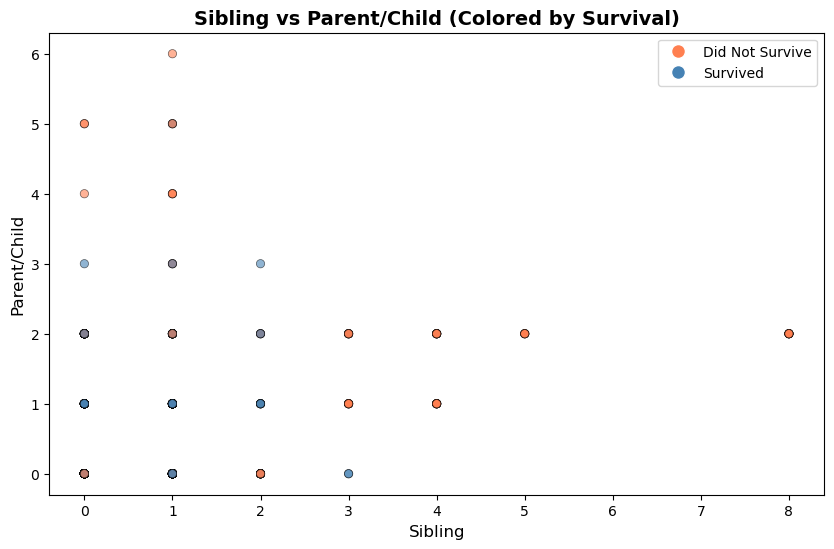

In [136]:
# Your Turn: Scatter Plot - SibSp vs Parch
# Write your code here!
plt.figure(figsize=(10, 6))

# Create colors based on survival
colors = df_titanic['Survived'].map({0: 'coral', 1: 'steelblue'})

plt.scatter(df_titanic['SibSp'], df_titanic['Parch'], 
            c=colors,
            alpha=0.6,
            edgecolor='black',
            linewidth=0.5)

plt.title('Sibling vs Parent/Child (Colored by Survival)', fontsize=14, fontweight='bold')
plt.xlabel('Sibling', fontsize=12)
plt.ylabel('Parent/Child', fontsize=12)

# Add a simple legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='coral', markersize=10, label='Did Not Survive'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Survived')]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()

---

# Section 6: Box Plots

Box plots (also called box-and-whisker plots) are fantastic for understanding data distribution AND spotting outliers.

## When to Use a Box Plot

**✅ USE box plots when:**
- Comparing the **distribution** of a numerical variable across different groups
- You want to see the **median, quartiles, and spread** of data
- **Spotting outliers** is important
- Comparing multiple groups side-by-side

**❌ DON'T use box plots when:**
- Your audience isn't familiar with them (they require explanation)
- You only have **one group** to show (a histogram might be clearer)
- You need to show the **exact shape** of the distribution (use a histogram)

---

**Think of it this way:** Box plots answer "How does the spread of this data compare across groups?"

### Understanding a Box Plot

```
        ┌─────┐
        │     │
    ────┼─────┼────  ← Whiskers (extend to min/max, excluding outliers)
        │     │
    ┌───┴─────┴───┐
    │      │      │  ← Box (middle 50% of data)
    │      │      │     Line inside = Median (middle value)
    └─────────────┘
    
         ●  ●       ← Outliers (individual points beyond whiskers)
```

1st class passengers: 216
2nd class passengers: 184
3rd class passengers: 491


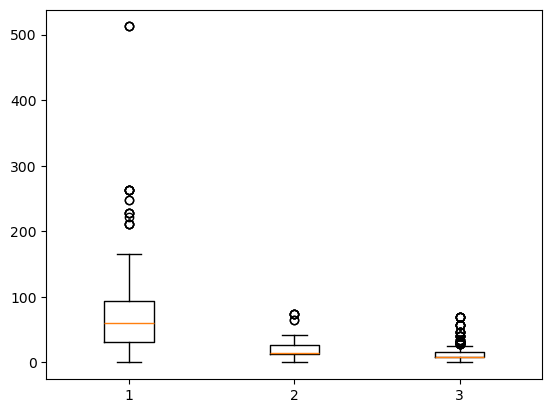

In [137]:
# Prepare data for each class using filtering
# This is the same filtering we learned yesterday!
# We filter to get just passengers from each class, then grab their Fare
fare_class1 = df_titanic[df_titanic['Pclass'] == 1]['Fare']
fare_class2 = df_titanic[df_titanic['Pclass'] == 2]['Fare']
fare_class3 = df_titanic[df_titanic['Pclass'] == 3]['Fare']

print(f"1st class passengers: {len(fare_class1)}")
print(f"2nd class passengers: {len(fare_class2)}")
print(f"3rd class passengers: {len(fare_class3)}")

# Basic box plot
plt.boxplot([fare_class1, fare_class2, fare_class3])
plt.show()

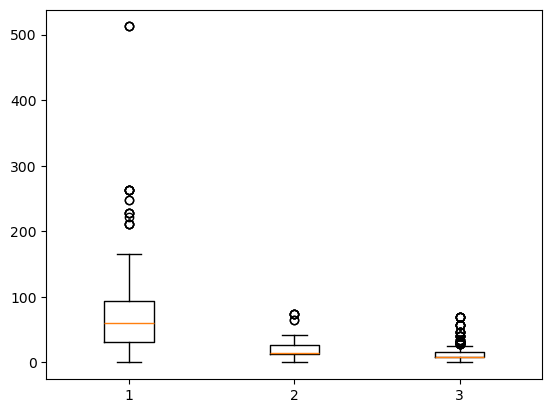

In [138]:
# Prepare data for each class
fare_class1 = df_titanic[df_titanic['Pclass'] == 1]['Fare']
fare_class2 = df_titanic[df_titanic['Pclass'] == 2]['Fare']
fare_class3 = df_titanic[df_titanic['Pclass'] == 3]['Fare']

# Basic box plot
plt.boxplot([fare_class1, fare_class2, fare_class3])
plt.show()

/var/folders/j0/k1sd2m5x5675pp_44swnzjzr0000gn/T/ipykernel_89948/3162888946.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data,


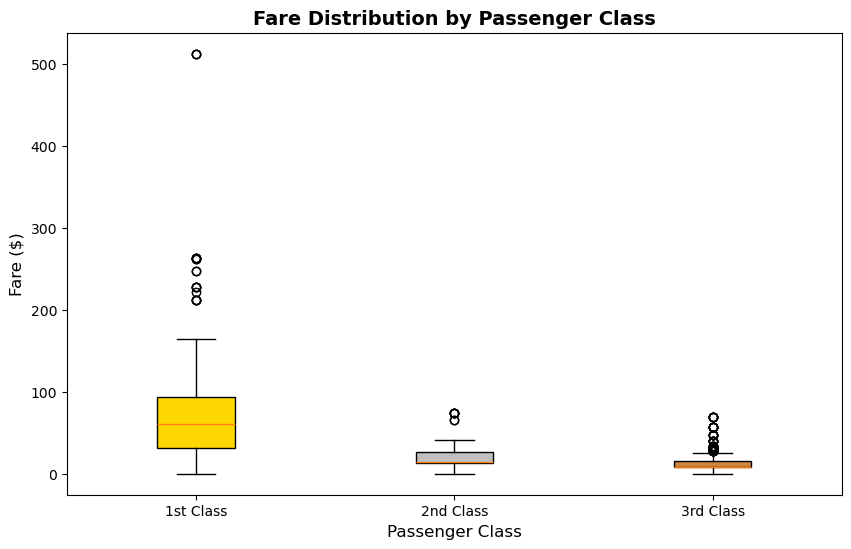

In [139]:
# Customized box plot
plt.figure(figsize=(10, 6))

box_data = [fare_class1, fare_class2, fare_class3]

bp = plt.boxplot(box_data, 
                  patch_artist=True,  # Allows us to fill with color
                  labels=['1st Class', '2nd Class', '3rd Class'])

# Color the boxes
colors = ['gold', 'silver', 'peru']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)

plt.show()

### 💡 Insight
Look at the **massive difference** in fares! 
- 1st class had the widest range and highest fares (those circles at the top are outliers paying $500+)
- 3rd class fares were tightly clustered at the bottom - most paid very little
- The median (line in the box) for 3rd class is barely visible because fares were so low

Survivors with known age: 290
Non-survivors with known age: 424


/var/folders/j0/k1sd2m5x5675pp_44swnzjzr0000gn/T/ipykernel_89948/3850285438.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([age_not_survived, age_survived],


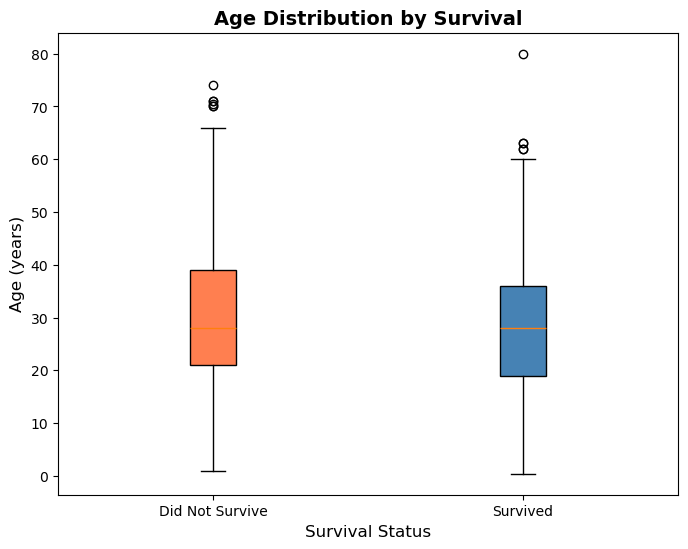

In [140]:
# Age distribution for survivors vs non-survivors
# Step 1: Filter for survivors (Survived == 1) and get their Age
# Step 2: Use dropna() to remove passengers with missing ages
age_survived = df_titanic[df_titanic['Survived'] == 1]['Age'].dropna()
age_not_survived = df_titanic[df_titanic['Survived'] == 0]['Age'].dropna()

print(f"Survivors with known age: {len(age_survived)}")
print(f"Non-survivors with known age: {len(age_not_survived)}")

plt.figure(figsize=(8, 6))

bp = plt.boxplot([age_not_survived, age_survived], 
                  patch_artist=True,
                  labels=['Did Not Survive', 'Survived'])

# Color the boxes
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')

plt.title('Age Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Survival Status', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)

plt.show()

/var/folders/j0/k1sd2m5x5675pp_44swnzjzr0000gn/T/ipykernel_89948/1032561337.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([age_not_survived, age_survived],


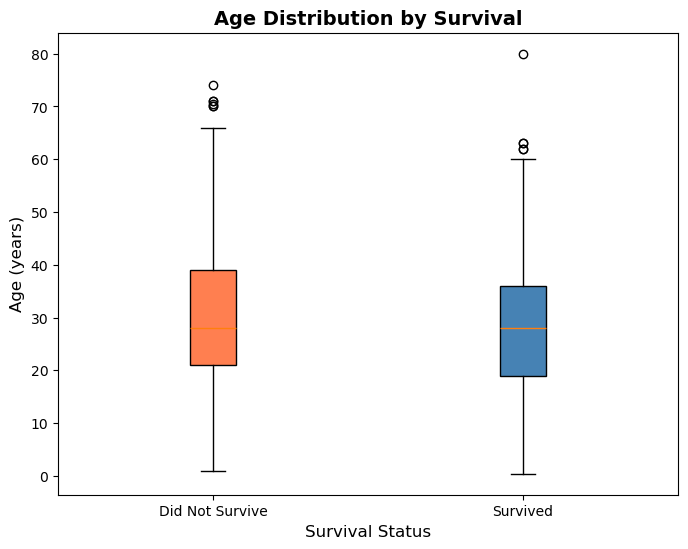

In [141]:
# Age distribution for survivors vs non-survivors
age_survived = df_titanic[df_titanic['Survived'] == 1]['Age'].dropna()
age_not_survived = df_titanic[df_titanic['Survived'] == 0]['Age'].dropna()

plt.figure(figsize=(8, 6))

bp = plt.boxplot([age_not_survived, age_survived], 
                  patch_artist=True,
                  labels=['Did Not Survive', 'Survived'])

# Color the boxes
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')

plt.title('Age Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Survival Status', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)

plt.show()

---

### 🎯 Your Turn: Box Plot Practice

**Challenge:** Create a box plot comparing the age distribution across the three embarkation ports (Southampton, Cherbourg, Queenstown).

**Your task:**
1. Filter the data to get ages for each embarkation port (S, C, Q)
2. Remember to use `.dropna()` to handle missing ages
3. Create a box plot comparing ages across all three ports
4. Add colors, a title, and axis labels
5. Use the full port names for the labels

**Hint:** Start like this:
```python
age_southampton = df_titanic[df_titanic['Embarked'] == 'S']['Age'].dropna()
age_cherbourg = df_titanic[df_titanic['Embarked'] == 'C']['Age'].dropna()
# ... continue for Queenstown
```

**Discussion question:** Do passengers from different ports have different age profiles? Which port had the youngest/oldest passengers on average?

---

### 🎯 Your Turn: Box Plot Practice

**Challenge:** Create a box plot comparing the age distribution across the three embarkation ports (Southampton, Cherbourg, Queenstown).

**Your task:**
1. Filter the data to get ages for each embarkation port (S, C, Q)
2. Remember to use `.dropna()` to handle missing ages
3. Create a box plot comparing ages across all three ports
4. Add colors, a title, and axis labels
5. Use the full port names for the labels

**Discussion question:** Do passengers from different ports have different age profiles? Which port had the youngest/oldest passengers on average?

/var/folders/j0/k1sd2m5x5675pp_44swnzjzr0000gn/T/ipykernel_89948/4201990335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([age_southampton, age_cherbourg, age_queenstown],


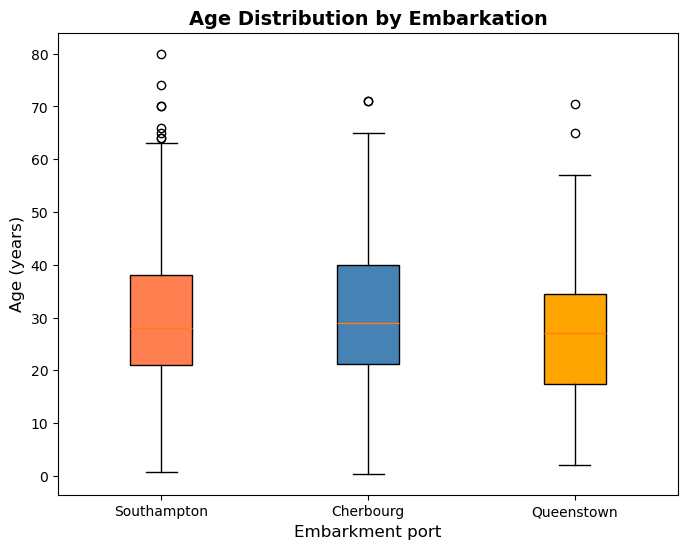

In [142]:
# Your Turn: Box Plot - Age by Embarkation Port
# Write your code here!

age_southampton = df_titanic[df_titanic['Embarked'] == 'S']['Age'].dropna()
age_cherbourg = df_titanic[df_titanic['Embarked'] == 'C']['Age'].dropna()
age_queenstown = df_titanic[df_titanic['Embarked'] == 'Q']['Age'].dropna()


plt.figure(figsize=(8, 6))

bp = plt.boxplot([age_southampton, age_cherbourg, age_queenstown], 
                  patch_artist=True,
                  labels=['Southampton', 'Cherbourg', 'Queenstown'])

# Color the boxes
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
bp['boxes'][2].set_facecolor('orange')

plt.title('Age Distribution by Embarkation', fontsize=14, fontweight='bold')
plt.xlabel('Embarkment port', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)

plt.show()

---

# Section 7: Putting It All Together

Let's review what we've learned and test your understanding!

## Quick Reference: Chart Selection Guide

| Question You're Asking | Best Chart Type |
|------------------------|----------------|
| How many of each category? | **Bar Chart** |
| How is this data distributed? | **Histogram** |
| What portion of the whole? | **Pie Chart** |
| Is there a relationship between X and Y? | **Scatter Plot** |
| How does the spread compare across groups? | **Box Plot** |

---

## 🧠 Quiz Time! Which Chart Would You Use?

For each question below, discuss with your classmates: **Which chart type would be best and why?**

### Question 1

**You want to show how many passengers embarked from each port (Southampton, Cherbourg, Queenstown).**

Which chart would you use?

<details>
<summary>Click to reveal answer</summary>

**Bar Chart** - You're comparing counts across categories (ports). Each port is a separate category.

</details>

### Question 2

**You want to see if older passengers tended to pay higher fares.**

Which chart would you use?

<details>
<summary>Click to reveal answer</summary>

**Scatter Plot** - You're looking for a relationship between two numerical variables (age and fare). Plot age on one axis, fare on the other, and look for patterns.

</details>

### Question 3

**You want to show that 38% of passengers survived and 62% did not.**

Which chart would you use?

<details>
<summary>Click to reveal answer</summary>

**Pie Chart** - You're showing parts of a whole (100% of passengers split into two groups). With only 2 categories, a pie chart works well here.

</details>

### Question 4

**You want to understand the age range of passengers - are most people young? Old? Evenly distributed?**

Which chart would you use?

<details>
<summary>Click to reveal answer</summary>

**Histogram** - You want to see the distribution/shape of a continuous variable (age). A histogram will show you where ages cluster and how they're spread out.

</details>

### Question 5

**You want to compare how fares varied between 1st, 2nd, and 3rd class, including seeing any extreme values (outliers).**

Which chart would you use?

<details>
<summary>Click to reveal answer</summary>

**Box Plot** - You're comparing the distribution of a numerical variable (fare) across categories (class), and you specifically want to see outliers. Box plots excel at this!

</details>

### Question 6 (Tricky!)

**You want to show the percentage breakdown of passengers by class: 24% 1st class, 21% 2nd class, 55% 3rd class.**

Which chart would you use? Is there more than one good option?

<details>
<summary>Click to reveal answer</summary>

**Either a Pie Chart OR a Bar Chart could work!**

- **Pie Chart**: Good because you're showing parts of a whole (100%) and you only have 3 categories
- **Bar Chart**: Also good, and might be clearer for comparing the exact percentages

The "right" answer often depends on what you want to emphasize. If you want to emphasize "3rd class was more than half the ship," a pie chart makes that visually obvious.

</details>

---

## Key Insights We Discovered Today

Through our visualizations, we learned:

1. **More women survived than men** (Bar Chart) - reflecting "women and children first"

2. **Only about 38% of passengers survived** (Pie Chart) - nearly 2 out of 3 did not make it

3. **Most passengers were young adults, 20-30 years old** (Histogram)

4. **3rd class made up over half the passengers** (Pie Chart)

5. **1st class passengers paid dramatically more** (Box Plot) - some paid $500+ while 3rd class paid under $20

6. **Higher fare passengers had better survival rates** (Scatter Plot) - likely 1st class with better access to lifeboats

---

**This is the power of data visualization!** We took 891 rows of numbers and turned them into clear, visual stories about the Titanic passengers.

---

## Wrap-Up

**Today you learned:**

✅ **Bar Charts** - Comparing categories

✅ **Histograms** - Showing distribution of numerical data

✅ **Pie Charts** - Showing parts of a whole

✅ **Scatter Plots** - Exploring relationships between two variables

✅ **Box Plots** - Comparing distributions and spotting outliers

**Most importantly:** Knowing **when to use** each chart is just as important as knowing **how to build** them!

---

*Great work today!*